In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd

In [3]:
original_fits = pd.read_csv("data/fit+pars_e1.csv")
original_fits["participant_id"] = original_fits["group"].astype(str).str.cat(original_fits["agent"].astype(str), sep="_")
original_fits = original_fits[original_fits['model'] == 'SG'].reset_index()
original_fits.head()

,index,agent,group,model,r2_SG,r2_AS,id,r2_VS,Unnamed: 0,r2_DB,fit,lambda,beta,tau,par,participant_id
0,3,1,0,SG,0.362297,0.384095,0,0.144045,0,0.359872,297.650844,0.720461,0.455930,0.019478,19.000000,0_1
1,7,2,0,SG,0.301433,0.393441,1,0.288942,3840,0.300501,356.928390,1.687182,0.006738,0.091126,19.000000,0_2
2,11,3,0,SG,0.486465,0.474588,2,0.475154,7680,0.461715,275.834417,1.571025,0.226598,0.033910,5.696640,0_3
3,15,4,0,SG,0.373570,0.369588,3,0.300039,11520,0.355000,336.473476,0.869698,0.433284,0.032035,17.732513,0_4
4,19,1,3,SG,0.218315,-0.953539,4,0.224414,120,0.321985,419.865220,2.064208,0.006738,0.092152,19.000000,3_1


In [4]:
replication_fits = pd.read_csv("data/replicate_fits_20250710_112632.csv")
replication_fits["participant_id"] = replication_fits["group"].astype(str).str.cat(
    replication_fits["agent"].astype(str), sep="_")
replication_fits.head()

,group,agent,nll,length_scale,beta,tau,observation_noise_social,participant_id
0,0,1,346.310894,0.811456,1.124196,0.058359,18.209322,0_1
1,0,2,365.160504,1.199571,0.411614,0.089398,16.593402,0_2
2,0,3,311.910516,2.275782,0.255916,0.063786,2.485412,0_3
3,0,4,340.053918,1.033854,0.756315,0.068829,14.909805,0_4
4,3,1,329.908236,0.743273,0.931176,0.048543,17.190635,3_1


In [5]:
df = pd.merge(original_fits, replication_fits, on='participant_id', suffixes=('_orig', '_replication'))
df.head()

,index,agent_orig,group_orig,model,r2_SG,r2_AS,id,r2_VS,Unnamed: 0,r2_DB,...,tau_orig,par,participant_id,group_replication,agent_replication,nll,length_scale,beta_replication,tau_replication,observation_noise_social
0,3,1,0,SG,0.362297,0.384095,0,0.144045,0,0.359872,...,0.019478,19.000000,0_1,0,1,346.310894,0.811456,1.124196,0.058359,18.209322
1,7,2,0,SG,0.301433,0.393441,1,0.288942,3840,0.300501,...,0.091126,19.000000,0_2,0,2,365.160504,1.199571,0.411614,0.089398,16.593402
2,11,3,0,SG,0.486465,0.474588,2,0.475154,7680,0.461715,...,0.033910,5.696640,0_3,0,3,311.910516,2.275782,0.255916,0.063786,2.485412
3,15,4,0,SG,0.373570,0.369588,3,0.300039,11520,0.355000,...,0.032035,17.732513,0_4,0,4,340.053918,1.033854,0.756315,0.068829,14.909805
4,19,1,3,SG,0.218315,-0.953539,4,0.224414,120,0.321985,...,0.092152,19.000000,3_1,3,1,329.908236,0.743273,0.931176,0.048543,17.190635


In [6]:
df = df.rename(columns={
    'lambda': 'length_scale_orig',
    'length_scale': 'length_scale_replication',
    'par': 'observation_noise_social_orig',
    'observation_noise_social': 'observation_noise_social_replication'
})
df.columns

Index(['index', 'agent_orig', 'group_orig', 'model', 'r2_SG', 'r2_AS', 'id',
       'r2_VS', 'Unnamed: 0', 'r2_DB', 'fit', 'length_scale_orig', 'beta_orig',
       'tau_orig', 'observation_noise_social_orig', 'participant_id',
       'group_replication', 'agent_replication', 'nll',
       'length_scale_replication', 'beta_replication', 'tau_replication',
       'observation_noise_social_replication'],
      dtype='object')

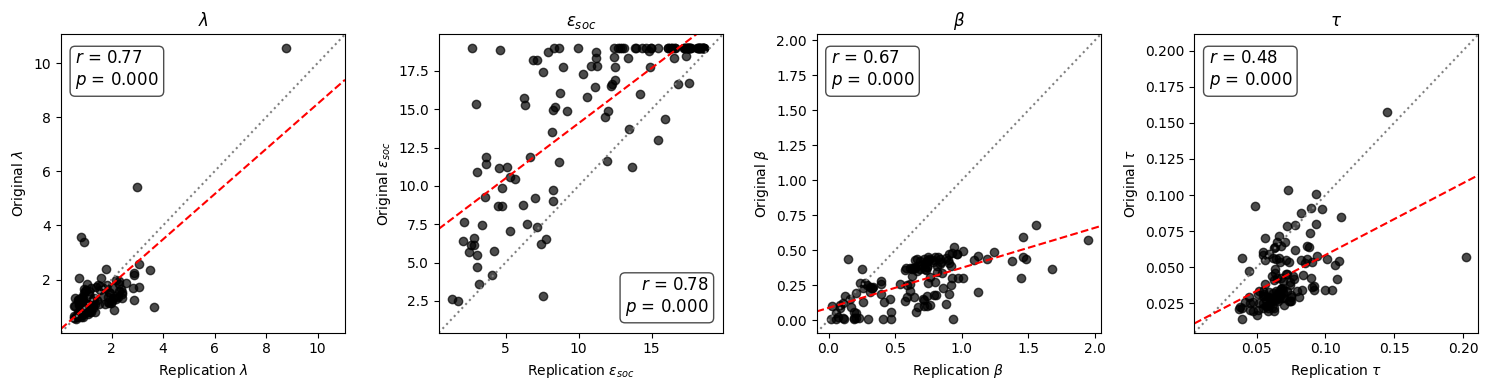

In [23]:
import scipy.stats as stats
def get_best_corner(x, y):
    # Normalize x and y to [0, 1] based on their min/max
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    
    corners = {
        'top_left':     ((x_norm <= 0.2) & (y_norm >= 0.8)).sum(),
        'top_right':    ((x_norm >= 0.8) & (y_norm >= 0.8)).sum(),
        'bottom_left':  ((x_norm <= 0.2) & (y_norm <= 0.2)).sum(),
        'bottom_right': ((x_norm >= 0.8) & (y_norm <= 0.2)).sum(),
    }
    best_corner = min(corners, key=corners.get)
    return best_corner

def corner_coords(corner):
    # Axes coordinates (x, y), and alignment
    coords = {
        'top_left':     (0.05, 0.95, 'left',  'top'),
        'top_right':    (0.95, 0.95, 'right', 'top'),
        'bottom_left':  (0.05, 0.05, 'left',  'bottom'),
        'bottom_right': (0.95, 0.05, 'right', 'bottom'),
    }
    return coords[corner]

params = ["$\\lambda$", "$\\epsilon_{soc}$", "$\\beta$", "$\\tau$"]
params_columns = ["length_scale", "observation_noise_social", "beta", "tau"]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

correlations = []
for idx, p in enumerate(params_columns):
    x = df[f'{p}_replication'].values.copy()
    y = df[f'{p}_orig'].values.copy()
    corr, pval = stats.pearsonr(x, y)
    correlations.append({'parameter': params[idx], 'corr': corr, 'pval': pval})

    # y[np.abs(y - np.mean(y)) > 2 * np.std(y)] = np.mean(y)
    # x[np.abs(x - np.mean(x)) > 2 * np.std(x)] = np.mean(x)
    
    # Scatter
    axes[idx].scatter(x, y, color='black', alpha=0.7)

    # Diagonal
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    pad = 0.05 * (max_val - min_val) if max_val > min_val else 1  # Fallback to 1 if zero-range
    axes[idx].set_xlim(min_val - pad, max_val + pad)
    axes[idx].set_ylim(min_val - pad, max_val + pad)
    axes[idx].plot([min_val - pad, max_val + pad], [min_val - pad, max_val + pad], color='gray', linestyle=':')

    # Fit line
    slope, intercept = np.polyfit(x, y, 1)
    reg_x = np.linspace(min_val - pad, max_val + pad, 100)
    reg_y = slope * reg_x + intercept
    axes[idx].plot(reg_x, reg_y, color='red', linestyle='--', label="OLS fit")

    # Annotate correlation
    best_corner = get_best_corner(x, y)
    cx, cy, halign, valign = corner_coords(best_corner)
    axes[idx].text(
        cx, cy,
        f"$r$ = {corr:.2f}\n$p$ = {pval:.3f}",
        transform=axes[idx].transAxes,
        horizontalalignment=halign,
        verticalalignment=valign,
        fontsize=12,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )
    axes[idx].set_xlabel(f"Replication {params[idx]}")
    axes[idx].set_ylabel(f"Original {params[idx]}")
    axes[idx].set_title(f"{params[idx]}")


plt.tight_layout()
plt.show()

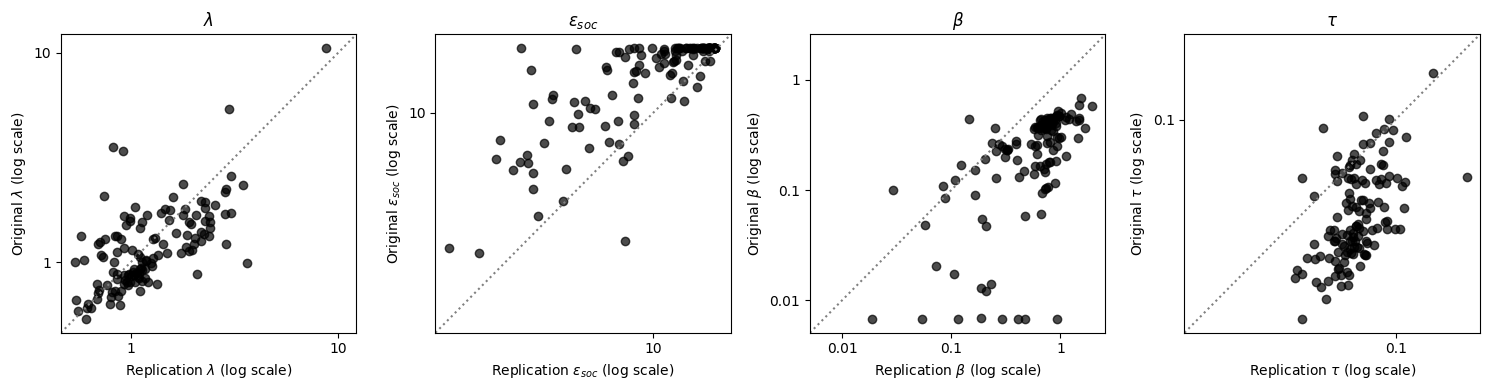

In [27]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

def get_best_corner(x, y):
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    corners = {
        'top_left':     ((x_norm <= 0.2) & (y_norm >= 0.8)).sum(),
        'top_right':    ((x_norm >= 0.8) & (y_norm >= 0.8)).sum(),
        'bottom_left':  ((x_norm <= 0.2) & (y_norm <= 0.2)).sum(),
        'bottom_right': ((x_norm >= 0.8) & (y_norm <= 0.2)).sum(),
    }
    best_corner = min(corners, key=corners.get)
    return best_corner

def corner_coords(corner):
    coords = {
        'top_left':     (0.05, 0.95, 'left',  'top'),
        'top_right':    (0.95, 0.95, 'right', 'top'),
        'bottom_left':  (0.05, 0.05, 'left',  'bottom'),
        'bottom_right': (0.95, 0.05, 'right', 'bottom'),
    }
    return coords[corner]

params = ["$\\lambda$", "$\\epsilon_{soc}$", "$\\beta$", "$\\tau$"]
params_columns = ["length_scale", "observation_noise_social", "beta", "tau"]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

correlations = []
for idx, p in enumerate(params_columns):
    x_raw = df[f'{p}_replication'].values
    y_raw = df[f'{p}_orig'].values
    
    # Mask out non-positive values
    mask = (x_raw > 0) & (y_raw > 0)
    x = np.log10(x_raw[mask])
    y = np.log10(y_raw[mask])
    
    corr, pval = stats.pearsonr(x, y)
    correlations.append({'parameter': params[idx], 'corr': corr, 'pval': pval})

    ax = axes[idx]
    ax.scatter(x, y, color='black', alpha=0.7)

    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    pad = 0.05 * (max_val - min_val) if max_val > min_val else 1
    ax.set_xlim(min_val - pad, max_val + pad)
    ax.set_ylim(min_val - pad, max_val + pad)
    ax.plot([min_val - pad, max_val + pad], [min_val - pad, max_val + pad], color='gray', linestyle=':')

    # LABELS
    ax.set_xlabel(f"Replication {params[idx]} (log scale)")
    ax.set_ylabel(f"Original {params[idx]} (log scale)")
    ax.set_title(f"{params[idx]}")

    # ---- TICKS: set original scale on log axis ----
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    # Calculate reasonable tick positions
    all_ticks = np.arange(np.floor(min(xlim[0], ylim[0])), np.ceil(max(xlim[1], ylim[1])) + 1)
    tick_labels = [f"{10**tick:.2g}" for tick in all_ticks]

    valid_xticks = (all_ticks >= xlim[0]) & (all_ticks <= xlim[1])
    valid_yticks = (all_ticks >= ylim[0]) & (all_ticks <= ylim[1])

    ax.set_xticks(all_ticks[valid_xticks])
    ax.set_yticks(all_ticks[valid_yticks])
    ax.set_xticklabels([tick_labels[i] for i, v in enumerate(valid_xticks) if v])
    ax.set_yticklabels([tick_labels[i] for i, v in enumerate(valid_yticks) if v])

plt.tight_layout()
plt.show()

